In [44]:
Pkg.add("Contour")

   Resolving package versions...
  No Changes to `C:\Users\imaan\.julia\environments\v1.10\Project.toml`
  No Changes to `C:\Users\imaan\.julia\environments\v1.10\Manifest.toml`


In [51]:
using PlutoUI; TableOfContents()
using LaTeXStrings
using DifferentialEquations 
using LinearAlgebra
using Plots
Plots.default(size = 600 .* (√2, 1), dpi = 250, linewidth = 3, margins = 5Plots.mm, label = false)
Plots.resetfontsizes(); Plots.scalefontsizes(1.2)

## A1 Optimal Control and Tipping Points 
 1) cx-(x-1)^2 * x - xy = 0 (Grass biomass does not increase or decrease)  <br />  xy = cx - (x-1)^2 * x  <br /> x = o or  y = c-(x-1)^2
2) xy-dy = 0 (Herbivore biomass  does not increase or decrease) <br /> y = 0 or x = d 



In [55]:
b = 0.1 # death rate grass
d = 1 # death rate herbivores
c = 0.7

f1(x, y) = c * x - (x * (x - 1)^2) - (x * y)
f2(x, y) = x * y - d * y

# Check if stable states
x = d
y = c - (d - 1)^2
println(f1(x, y))

x = 0
y = 3 # arbitrary
println(f1(x, y))

x = d
println(f2(x, y))

x = 4 # arbitrary
y = 0
println(f2(x, y))

0.0
0.0
0
0


In [56]:
nullcline_x1(c, x) = c - (x - 1)^2

nullcline_x2() = 0

nullcline_y1(d) = d

nullcline_y2() = 0

x_axis = range(0, stop=1.9, length=1000)
x_nullcline1 = nullcline_x1.(c, x_axis)
x_nullcline2 = nullcline_x2()
y_nullcline1 = nullcline_y1(d)
y_nullcline2 = nullcline_y2()


0

B) Compute the steady states and add them to the figure. One of these steady states is a grassrich, no-herbivore steady state: which one?
- steady state whe, fx_1 = 0 and fx_2 = 0, so finding intesersect of nullclines will show steady states. 
- Steady state 1: plug in x = d = 1 (given) into f1(x) = 0 --> y = .7 - (1-1)^2 * 1 = .7, so steady state 1 at (1,.7)
- Steady state 2: solve y = 0 = f1(x) .7-(x-1)^2 * x = 0, Solving using abc gives $$x = 1 +/-  .5 * sqrt(28/10)$$
- Steady stae 4: 

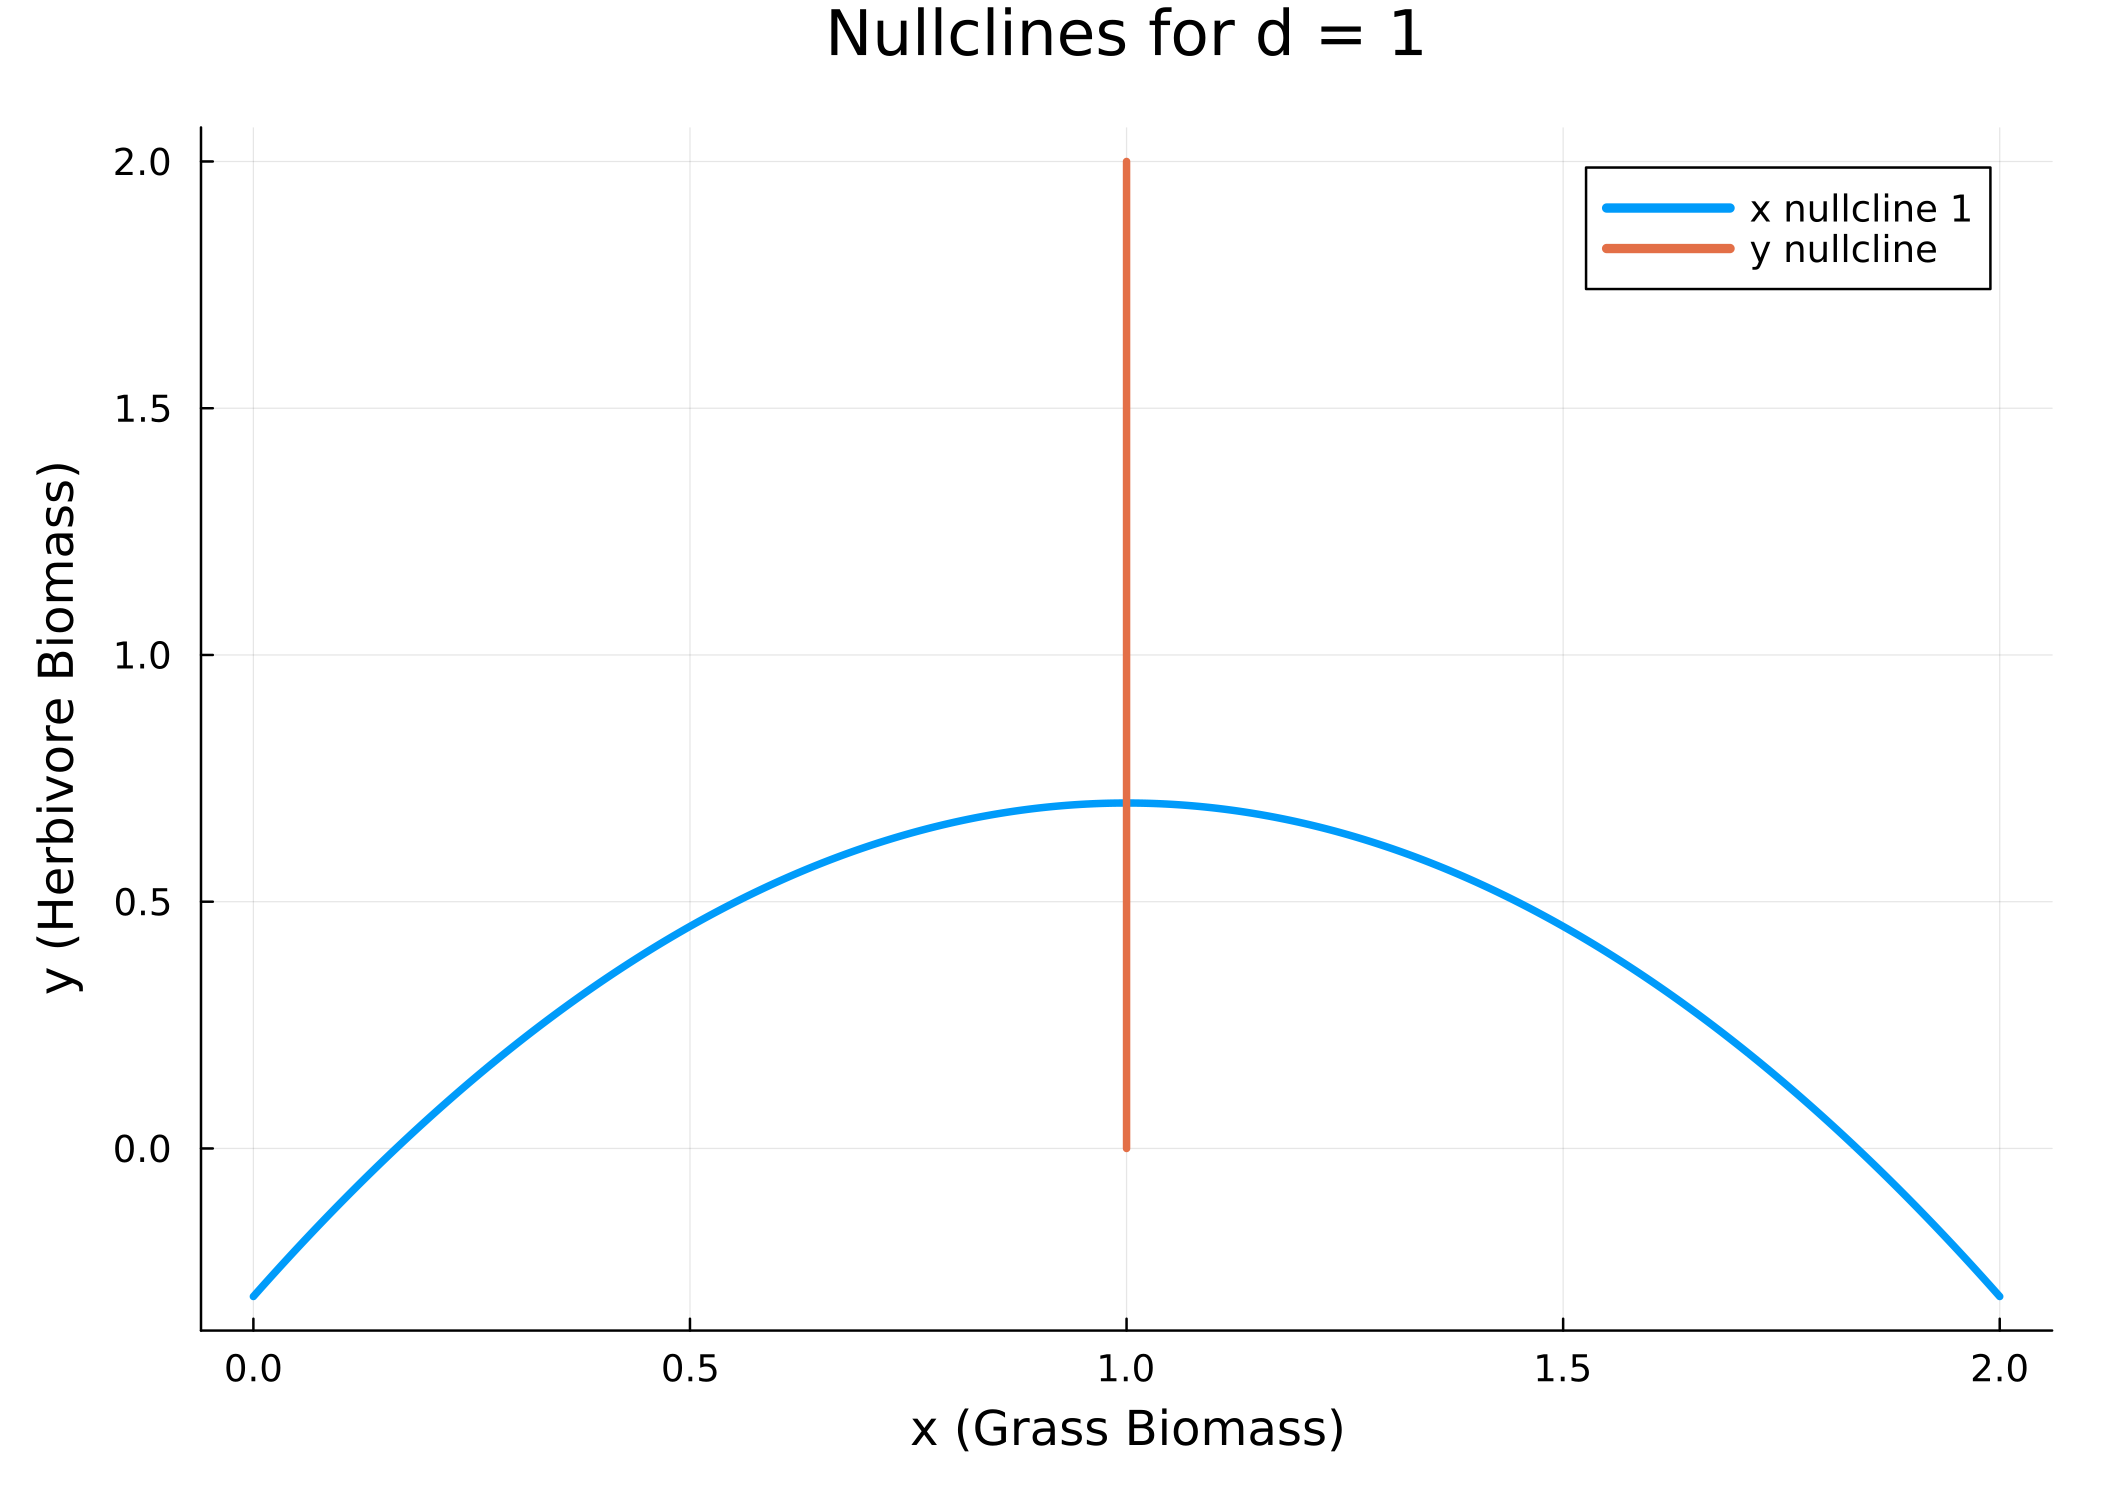

In [71]:
using Plots

function nullcline_x1(c, x)
    return c .- (x .- 1).^2
end

function nullcline_x2(x, y)
    return 0 
end

function nullcline_y(d, x)
    return d .* ones(length(x))
end




c = 0.7
d = 1.0

axis = range(0, stop=2, length=1000)
x_nullcline1 = nullcline_x1(c, x_axis)
x_nullcline2 = nullcline_x2(axis, axis)


y_nullcline1 = nullcline_y(d, x_axis)

plot(x_axis, x_nullcline1, label="x nullcline 1", grid=true)
plot!(axis, x_nullcline2, label="x nullcline 2")

plot!(y_nullcline1, axis, label="y nullcline")


title!("Nullclines for d = 1")
xlabel!("x (Grass Biomass)")
ylabel!("y (Herbivore Biomass)")

In [60]:
using Pkg
Pkg.add("Plots")

   Resolving package versions...
  No Changes to `C:\Users\imaan\.julia\environments\v1.10\Project.toml`
  No Changes to `C:\Users\imaan\.julia\environments\v1.10\Manifest.toml`


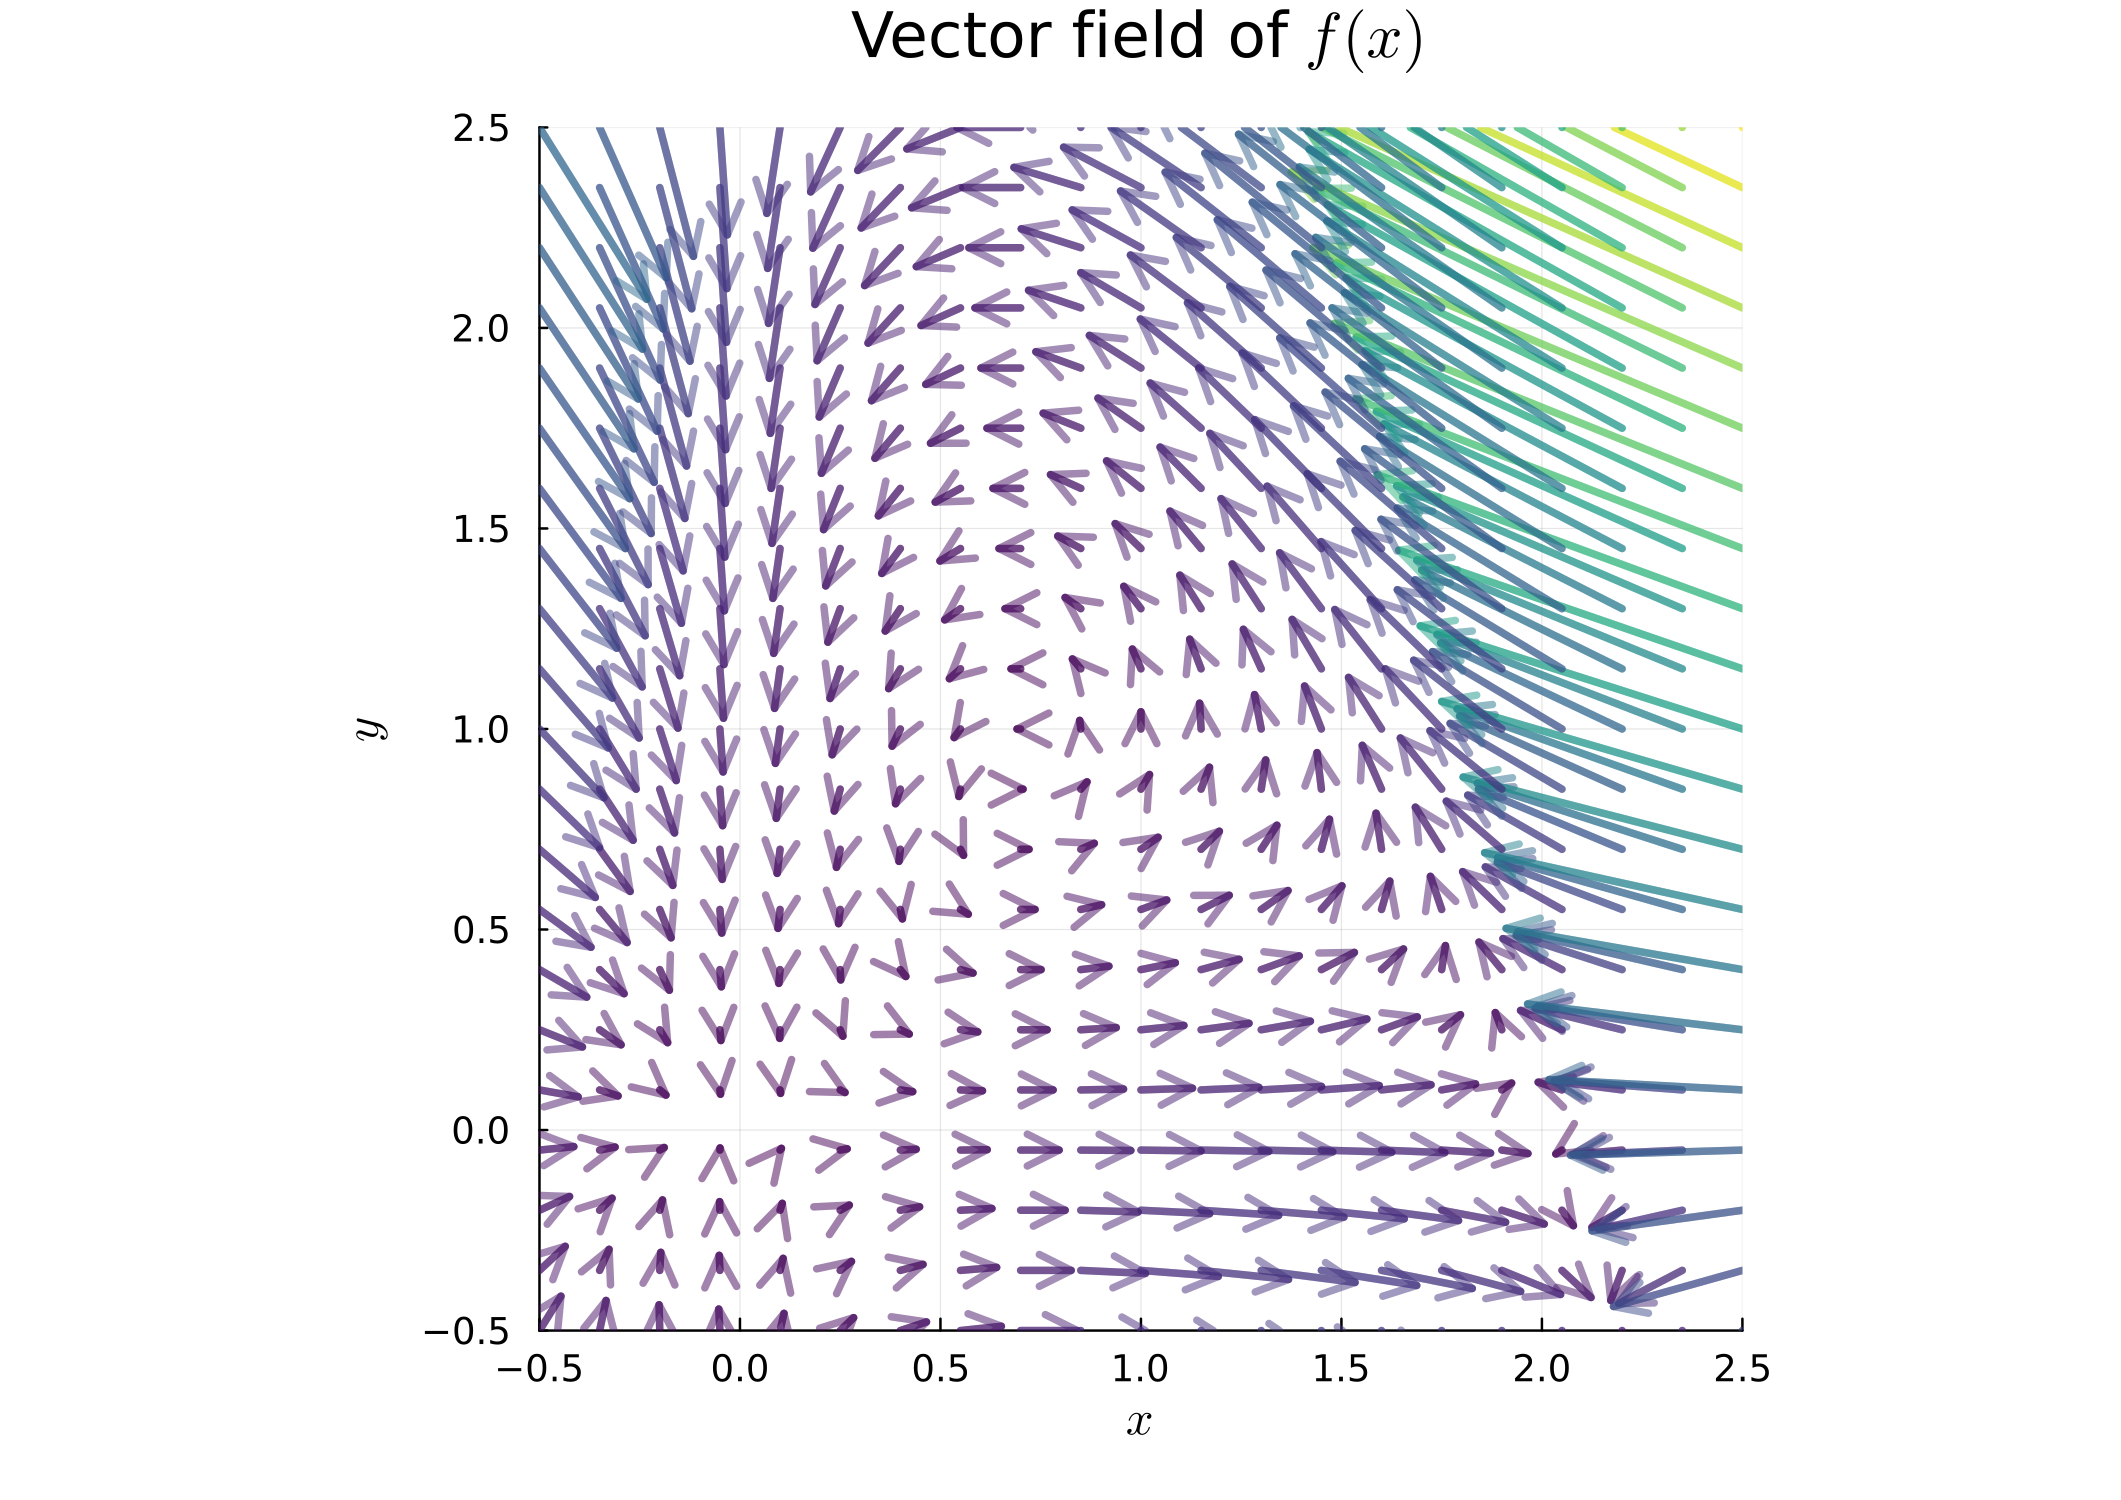

In [54]:
begin
	vectorfield(xs, ys, g, plotargs...; plotkwargs...) = vectorfield!(plot(), xs, ys, g, plotargs...; plotkwargs...)
	
	function vectorfield!(figure, xs, ys, g, plotargs...; plotkwargs...)
	  N, M = length(xs), length(ys)
	  Δx = last(extrema(xs)) - first(extrema(xs))
	  
	  xm, ym = (repeat(xs, outer=length(ys)), repeat(ys, inner=length(xs)))
	  
	  field = ((x, y) -> g([x, y])).(xm, ym)
	  
	  scale = Δx / N
	  u = @. scale * first(field)
	  v = @. scale * last(field)
	  
	  quiver!(
		  figure, xm, ym, 
		  quiver = (u, v), line_z=repeat(norm.(field), inner=4), 
		  plotargs...; plotkwargs...
	  )
	end
end;

function f!(dx, x, params, t)
	c, δ = params
	dx[1] = c * x[1] - (x[1] - 1)^2 * x[1] - x[1] * x[2]
	dx[2] = x[1] * x[2] - δ * x[2]
end;

function f(x, params, t)
	dx = similar(x)
	f!(dx, x, params, t)
	return dx
end;


function nullcline_x1(c, x)
	return c - (x - 1)^2
end



begin
	xs = -.5:0.15:2.5
	params = (1.0, 0.7)  # Example values for c and δ
	vecfig = vectorfield(xs, xs, x -> f(x, params, 0.); xlabel = L"x", ylabel = L"y", aspect_ratio = 1, xlims = extrema(xs), ylims = extrema(xs), c = :viridis, title = L"Vector field of $f(x)$", colorbar = false, alpha = 0.5)

end
